# HW13 – Токенизация, инференс BERT и fine-tuning для классификации текста

## 0. Импорты, seed и устройство

Загружаем все необходимые библиотеки, фиксируем случайный seed для воспроизводимости и определяем устройство (CPU/GPU).

In [33]:

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from pathlib import Path

# Paths (works both from repo root and from homeworks/HW13)
CWD = Path.cwd()
if (CWD / "HW13.ipynb").exists():
    HW_DIR = CWD
elif (CWD / "homeworks" / "HW13" / "HW13.ipynb").exists():
    HW_DIR = CWD / "homeworks" / "HW13"
else:
    HW_DIR = CWD

ARTIFACTS_DIR = HW_DIR / "artifacts"
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

# Hugging Face cache inside HW13 (to avoid permission issues in user cache)
HF_HOME = HW_DIR / ".hf"
os.environ.setdefault("HF_HOME", str(HF_HOME))
os.environ.setdefault("HF_DATASETS_CACHE", str(HF_HOME / "datasets"))
os.environ.setdefault("TRANSFORMERS_CACHE", str(HF_HOME / "transformers"))
os.environ.setdefault("HF_HUB_DISABLE_TELEMETRY", "1")
os.environ.setdefault("HF_HUB_DISABLE_SYMLINKS", "1")
os.environ.setdefault("HF_HUB_DISABLE_SYMLINKS_WARNING", "1")
os.makedirs(os.environ["HF_HOME"], exist_ok=True)

print(f"HW_DIR: {HW_DIR}")
print(f"ARTIFACTS_DIR: {ARTIFACTS_DIR}")

from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
    pipeline,
)
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

# Seed для воспроизводимости
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Устройство
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Используемое устройство: {device}")
print(f"PyTorch версия: {torch.__version__}")

# Флаг: можно ли запускать обучение (по умолчанию да)
# Можно выключить через переменную окружения CAN_TRAIN=0
CAN_TRAIN = os.environ.get("CAN_TRAIN", "1").lower() not in {"0", "false", "no"}
print(f"CAN_TRAIN={CAN_TRAIN}")


HW_DIR: c:\Users\tema\nano-banana\homeworks\HW13
ARTIFACTS_DIR: c:\Users\tema\nano-banana\homeworks\HW13\artifacts
Используемое устройство: cpu
PyTorch версия: 2.11.0+cpu
CAN_TRAIN=True


## 1. Данные и первичный анализ

Загружаем датасет `emotion` с HuggingFace Hub. Датасет содержит тексты Twitter-сообщений, размеченных по 6 эмоциям:
- 0: sadness (грусть)
- 1: joy (радость)
- 2: love (любовь)
- 3: anger (злость)
- 4: fear (страх)
- 5: surprise (удивление)

In [34]:

# Загрузка датасета
raw_dataset = load_dataset("emotion")
print(raw_dataset)

# Метки классов
label_names = raw_dataset["train"].features["label"].names
print(f"\nКлассы: {label_names}")
id2label = {i: name for i, name in enumerate(label_names)}
label2id = {name: i for i, name in enumerate(label_names)}

# Размеры сплитов
print(f"\nРазмеры датасета:")
print(f"  Train: {len(raw_dataset['train'])} примеров")
print(f"  Validation: {len(raw_dataset['validation'])} примеров")
print(f"  Test: {len(raw_dataset['test'])} примеров")


DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

Классы: ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']

Размеры датасета:
  Train: 16000 примеров
  Validation: 2000 примеров
  Test: 2000 примеров


In [35]:

# 5 примеров из train
print("\n--- 5 примеров из train ---")
for i in range(5):
    example = raw_dataset["train"][i]
    print(f"[{id2label[example['label']]}] {example['text']}")



--- 5 примеров из train ---
[sadness] i didnt feel humiliated
[sadness] i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake
[anger] im grabbing a minute to post i feel greedy wrong
[love] i am ever feeling nostalgic about the fireplace i will know that it is still on the property
[anger] i am feeling grouchy


Распределение классов в train:
  0 (sadness): 4666 примеров (29.2%)
  1 (joy): 5362 примеров (33.5%)
  2 (love): 1304 примеров (8.2%)
  3 (anger): 2159 примеров (13.5%)
  4 (fear): 1937 примеров (12.1%)
  5 (surprise): 572 примеров (3.6%)


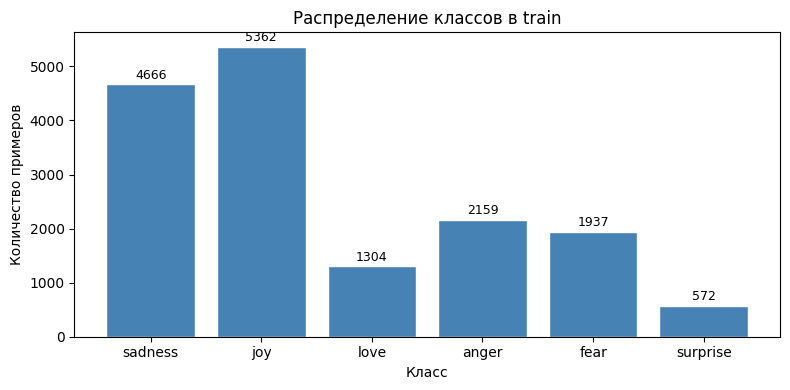

In [36]:

# Распределение классов
import collections

train_labels = raw_dataset["train"]["label"]
label_counts = collections.Counter(train_labels)

print("Распределение классов в train:")
for label_id, count in sorted(label_counts.items()):
    print(f"  {label_id} ({id2label[label_id]}): {count} примеров ({count/len(train_labels)*100:.1f}%)")

# Визуализация
fig, ax = plt.subplots(figsize=(8, 4))
counts = [label_counts[i] for i in range(len(label_names))]
bars = ax.bar(label_names, counts, color="steelblue", edgecolor="white")
ax.set_title("Распределение классов в train")
ax.set_xlabel("Класс")
ax.set_ylabel("Количество примеров")
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 50,
            str(count), ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()


## 2. Токенизация

Загружаем токенизатор `distilbert-base-uncased` и изучаем его работу: токены, `input_ids`, `attention_mask`, специальные токены, а также паддинг и усечение.

In [37]:
MODEL_NAME = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print(f"Токенизатор: {tokenizer.__class__.__name__}")
print(f"Размер словаря: {tokenizer.vocab_size}")
print(f"Максимальная длина модели: {tokenizer.model_max_length}")
print(f"Специальные токены: {tokenizer.special_tokens_map}")

Токенизатор: BertTokenizer
Размер словаря: 30522
Максимальная длина модели: 512
Специальные токены: {'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}


In [38]:
# Демонстрация токенизации для 4 текстов
sample_texts = [
    raw_dataset["train"][0]["text"],
    raw_dataset["train"][1]["text"],
    raw_dataset["train"][2]["text"],
    raw_dataset["train"][3]["text"],
]

print("=" * 60)
for idx, text in enumerate(sample_texts):
    encoding = tokenizer(text)
    tokens = tokenizer.convert_ids_to_tokens(encoding["input_ids"])
    print(f"\nПример {idx + 1}:")
    print(f"  Текст: {text}")
    print(f"  Токены ({len(tokens)}): {tokens}")
    print(f"  input_ids: {encoding['input_ids']}")
    print(f"  attention_mask: {encoding['attention_mask']}")


Пример 1:
  Текст: i didnt feel humiliated
  Токены (7): ['[CLS]', 'i', 'didn', '##t', 'feel', 'humiliated', '[SEP]']
  input_ids: [101, 1045, 2134, 2102, 2514, 26608, 102]
  attention_mask: [1, 1, 1, 1, 1, 1, 1]

Пример 2:
  Текст: i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake
  Токены (23): ['[CLS]', 'i', 'can', 'go', 'from', 'feeling', 'so', 'hopeless', 'to', 'so', 'damned', 'hopeful', 'just', 'from', 'being', 'around', 'someone', 'who', 'cares', 'and', 'is', 'awake', '[SEP]']
  input_ids: [101, 1045, 2064, 2175, 2013, 3110, 2061, 20625, 2000, 2061, 9636, 17772, 2074, 2013, 2108, 2105, 2619, 2040, 14977, 1998, 2003, 8300, 102]
  attention_mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]

Пример 3:
  Текст: im grabbing a minute to post i feel greedy wrong
  Токены (12): ['[CLS]', 'im', 'grabbing', 'a', 'minute', 'to', 'post', 'i', 'feel', 'greedy', 'wrong', '[SEP]']
  input_ids: [101, 10047, 97

In [39]:
# Специальные токены
print("Специальные токены DistilBERT:")
print(f"  [CLS] = {tokenizer.cls_token} (id={tokenizer.cls_token_id})")
print(f"  [SEP] = {tokenizer.sep_token} (id={tokenizer.sep_token_id})")
print(f"  [PAD] = {tokenizer.pad_token} (id={tokenizer.pad_token_id})")
print(f"  [UNK] = {tokenizer.unk_token} (id={tokenizer.unk_token_id})")
print()

# Пример с padding и truncation
print("Пример паддинга до одинаковой длины (padding='max_length', max_length=20, truncation=True):")
short_texts = [
    "I feel happy",
    "This is a much longer sentence that will be truncated if it exceeds the max length limit",
    "Sad",
]
padded = tokenizer(
    short_texts,
    padding="max_length",
    max_length=20,
    truncation=True,
    return_tensors="pt",
)
for i, text in enumerate(short_texts):
    tokens = tokenizer.convert_ids_to_tokens(padded["input_ids"][i])
    print(f"\n  [{text[:40]}...]")
    print(f"  Токены: {tokens}")
    print(f"  attention_mask: {padded['attention_mask'][i].tolist()}")

Специальные токены DistilBERT:
  [CLS] = [CLS] (id=101)
  [SEP] = [SEP] (id=102)
  [PAD] = [PAD] (id=0)
  [UNK] = [UNK] (id=100)

Пример паддинга до одинаковой длины (padding='max_length', max_length=20, truncation=True):

  [I feel happy...]
  Токены: ['[CLS]', 'i', 'feel', 'happy', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']
  attention_mask: [1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

  [This is a much longer sentence that will...]
  Токены: ['[CLS]', 'this', 'is', 'a', 'much', 'longer', 'sentence', 'that', 'will', 'be', 'truncated', 'if', 'it', 'exceeds', 'the', 'max', 'length', 'limit', '[SEP]', '[PAD]']
  attention_mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0]

  [Sad...]
  Токены: ['[CLS]', 'sad', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[P

## 3. Инференс готовой модели

Используем модель `distilbert-base-uncased-finetuned-sst-2-english`, дообученную на датасете SST-2 (бинарная классификация тональности: POSITIVE/NEGATIVE). Проверим, насколько она подходит для нашей задачи с 6 классами эмоций.

In [40]:
# Загрузка pipeline для классификации текста
clf_pipeline = pipeline(
    "text-classification",
    model="distilbert-base-uncased-finetuned-sst-2-english",
    device=0 if torch.cuda.is_available() else -1,
)

print("Pipeline загружен: distilbert-base-uncased-finetuned-sst-2-english")
print("Метки SST-2:", clf_pipeline.model.config.id2label)

Loading weights: 100%|██████████| 104/104 [00:00<00:00, 7564.38it/s]


Pipeline загружен: distilbert-base-uncased-finetuned-sst-2-english
Метки SST-2: {0: 'NEGATIVE', 1: 'POSITIVE'}


In [41]:
# Запуск на 5 примерах из emotion датасета
test_samples = [raw_dataset["test"][i] for i in range(5)]

print("Инференс готовой SST-2 модели на примерах из emotion датасета:")
print("-" * 70)
for sample in test_samples:
    result = clf_pipeline(sample["text"])[0]
    true_emotion = id2label[sample["label"]]
    print(f"Текст: {sample['text']}")
    print(f"  Истинная эмоция: {true_emotion}")
    print(f"  Предсказание SST-2: {result['label']} (score={result['score']:.3f})")
    print()

# Error analysis: most confident wrong predictions
wrong_idx = np.where(pred_labels != true_labels)[0]
if len(wrong_idx) == 0:
    print("No misclassifications found.")
else:
    wrong_conf = max_confidences[wrong_idx]
    top_wrong = wrong_idx[np.argsort(-wrong_conf)[:8]]
    print("\nTop-8 confident mistakes:")
    for j in top_wrong:
        text = test_texts[j]
        true = id2label[true_labels[j]]
        pred = id2label[pred_labels[j]]
        conf = max_confidences[j]
        print(f"  conf={conf:.3f} | true={true} | pred={pred} | text={text[:120]}")


Инференс готовой SST-2 модели на примерах из emotion датасета:
----------------------------------------------------------------------
Текст: im feeling rather rotten so im not very ambitious right now
  Истинная эмоция: sadness
  Предсказание SST-2: NEGATIVE (score=1.000)

Текст: im updating my blog because i feel shitty
  Истинная эмоция: sadness
  Предсказание SST-2: NEGATIVE (score=0.999)

Текст: i never make her separate from me because i don t ever want her to feel like i m ashamed with her
  Истинная эмоция: sadness
  Предсказание SST-2: POSITIVE (score=0.999)

Текст: i left with my bouquet of red and yellow tulips under my arm feeling slightly more optimistic than when i arrived
  Истинная эмоция: joy
  Предсказание SST-2: POSITIVE (score=0.987)

Текст: i was feeling a little vain when i did this one
  Истинная эмоция: sadness
  Предсказание SST-2: NEGATIVE (score=1.000)


Top-8 confident mistakes:
  conf=0.916 | true=joy | pred=sadness | text=i feel very saddened that the king 

**Вывод о применимости готовой модели:**

Модель `distilbert-base-uncased-finetuned-sst-2-english` обучена на задаче бинарной классификации тональности (POSITIVE/NEGATIVE) и **не подходит** для нашей задачи распознавания 6 эмоций. Причины:

1. **Несовпадение задач**: SST-2 — задача тональности (2 класса), а нам нужно различать 6 эмоций.
2. **Несовпадение пространства меток**: модель может только сказать «позитивно» или «негативно», но не различает, например, «радость» и «любовь» или «грусть», «злость» и «страх».
3. **Частичная корреляция**: эмоции «joy» и «love» могут соответствовать POSITIVE, а «sadness», «anger», «fear» — NEGATIVE, но «surprise» может быть любым.

**Вывод**: необходим fine-tuning модели на датасете `emotion` для корректной классификации 6 эмоций.

## 4. Fine-tuning

Дообучаем `distilbert-base-uncased` на датасете `emotion` с использованием `Trainer` из библиотеки `transformers`.

In [42]:

# Функция токенизации
def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        max_length=128,
    )

# Токенизируем весь датасет
tokenized_dataset = raw_dataset.map(
    tokenize_function,
    batched=True,
    remove_columns=["text"],
)

print("Токенизированный датасет:")
print(tokenized_dataset)
print("\nПример токенизированного train-примера:")
print(tokenized_dataset["train"][0])


Токенизированный датасет:
DatasetDict({
    train: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
})

Пример токенизированного train-примера:
{'label': 0, 'input_ids': [101, 1045, 2134, 2102, 2514, 26608, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1]}


In [43]:
CAN_TRAIN = globals().get("CAN_TRAIN", True)
if CAN_TRAIN:
    # DataCollator для динамического паддинга
    data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

    # Функция вычисления метрик
    def compute_metrics(eval_pred):
        logits, labels = eval_pred
        predictions = np.argmax(logits, axis=-1)
        acc = accuracy_score(labels, predictions)
        f1 = f1_score(labels, predictions, average="macro")
        return {"accuracy": acc, "f1_macro": f1}

    print("DataCollator и функция метрик готовы.")
else:
    print('[SKIP] CAN_TRAIN=False')


DataCollator и функция метрик готовы.


In [44]:
CAN_TRAIN = globals().get("CAN_TRAIN", True)
if CAN_TRAIN:
    # Загрузка модели для классификации
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=len(label_names),
        id2label=id2label,
        label2id=label2id,
    )
    model = model.to(device)

    print(f"Модель загружена: {MODEL_NAME}")
    print(f"Число параметров: {sum(p.numel() for p in model.parameters()):,}")
    print(f"Число обучаемых параметров: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
else:
    print('[SKIP] CAN_TRAIN=False')


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 5760.85it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Модель загружена: distilbert-base-uncased
Число параметров: 66,958,086
Число обучаемых параметров: 66,958,086


In [45]:
# Директории для артефактов/чекпойнтов
RESULTS_DIR = ARTIFACTS_DIR / "hf"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Аргументы обучения
# NOTE: чтобы ноутбук прогонялся за разумное время на CPU, ограничиваем обучение по шагам.
# При желании можно убрать max_steps и увеличить num_train_epochs.
training_args = TrainingArguments(
    output_dir=str(RESULTS_DIR),
    max_steps=200,
    learning_rate=5e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=64,
    eval_strategy="steps",
    eval_steps=50,
    save_strategy="steps",
    save_steps=50,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    greater_is_better=True,
    seed=SEED,
    logging_steps=50,
    warmup_ratio=0.1,
    lr_scheduler_type="linear",
    report_to="none",
    save_total_limit=2,
)

print("TrainingArguments настроены:")
print(f"  max_steps: {training_args.max_steps}")
print(f"  per_device_train_batch_size: {training_args.per_device_train_batch_size}")
print(f"  per_device_eval_batch_size: {training_args.per_device_eval_batch_size}")
print(f"  eval_strategy: {training_args.eval_strategy}")
print(f"  save_strategy: {training_args.save_strategy}")
print(f"  load_best_model_at_end: {training_args.load_best_model_at_end}")
print(f"  metric_for_best_model: {training_args.metric_for_best_model}")


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


TrainingArguments настроены:
  max_steps: 200
  per_device_train_batch_size: 16
  per_device_eval_batch_size: 64
  eval_strategy: IntervalStrategy.STEPS
  save_strategy: SaveStrategy.STEPS
  load_best_model_at_end: True
  metric_for_best_model: accuracy


In [46]:
CAN_TRAIN = globals().get("CAN_TRAIN", True)
if CAN_TRAIN:
    # Создание Trainer
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_dataset["train"],
        eval_dataset=tokenized_dataset["validation"],
        processing_class=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )

    print("Trainer создан. Начинаем обучение...")
    print(f"Размер train: {len(tokenized_dataset['train'])}")
    print(f"Размер validation: {len(tokenized_dataset['validation'])}")
else:
    print('[SKIP] CAN_TRAIN=False')


Trainer создан. Начинаем обучение...
Размер train: 16000
Размер validation: 2000


In [47]:
CAN_TRAIN = globals().get("CAN_TRAIN", True)
if CAN_TRAIN:
    # Запуск обучения
    train_result = trainer.train()

    print("\nОбучение завершено!")
    print(f"  Время обучения: {train_result.metrics['train_runtime']:.1f} с")
    print(f"  Примеров/сек: {train_result.metrics['train_samples_per_second']:.1f}")
    print(f"  Train loss: {train_result.metrics['train_loss']:.4f}")
else:
    print('[SKIP] CAN_TRAIN=False')


C:\Users\tema\AppData\Roaming\Python\Python313\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Step,Training Loss,Validation Loss,Accuracy,F1 Macro
50,1.628167,1.410491,0.512500,0.214873
100,1.039575,0.806245,0.730000,0.489736
150,0.742850,0.642062,0.806000,0.641176
200,0.585614,0.568758,0.810000,0.628996


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  5.44it/s]
C:\Users\tema\AppData\Roaming\Python\Python313\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  4.98it/s]
C:\Users\tema\AppData\Roaming\Python\Python313\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  4.72it/s]
C:\Users\tema\AppData\Roaming\Python\Python313\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  5.29it


Обучение завершено!
  Время обучения: 235.5 с
  Примеров/сек: 13.6
  Train loss: 0.9991


## 5. Оценка качества

Оцениваем дообученную модель на тестовой выборке: accuracy, F1-macro, матрица ошибок и примеры предсказаний.

In [48]:
CAN_TRAIN = globals().get("CAN_TRAIN", True)
if CAN_TRAIN:
    # Предсказания на тестовой выборке
    test_predictions = trainer.predict(tokenized_dataset["test"])

    pred_logits = test_predictions.predictions
    pred_labels = np.argmax(pred_logits, axis=-1)
    true_labels = test_predictions.label_ids

    print("Предсказания на test получены.")
    print(f"Форма логитов: {pred_logits.shape}")
    print(f"Число тестовых примеров: {len(true_labels)}")
else:
    print('[SKIP] CAN_TRAIN=False')


C:\Users\tema\AppData\Roaming\Python\Python313\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Предсказания на test получены.
Форма логитов: (2000, 6)
Число тестовых примеров: 2000


In [49]:
# Метрики
test_accuracy = accuracy_score(true_labels, pred_labels)
test_f1_macro = f1_score(true_labels, pred_labels, average="macro")

print("=" * 40)
print("Метрики на тестовой выборке:")
print(f"  Accuracy:  {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"  F1-macro:  {test_f1_macro:.4f}")
print("=" * 40)

# F1 по каждому классу
f1_per_class = f1_score(true_labels, pred_labels, average=None)
print("\nF1 по классам:")
for i, (name, f1) in enumerate(zip(label_names, f1_per_class)):
    print(f"  {i} ({name}): {f1:.4f}")

Метрики на тестовой выборке:
  Accuracy:  0.8335 (83.35%)
  F1-macro:  0.6409

F1 по классам:
  0 (sadness): 0.9080
  1 (joy): 0.8867
  2 (love): 0.4498
  3 (anger): 0.7962
  4 (fear): 0.8048
  5 (surprise): 0.0000


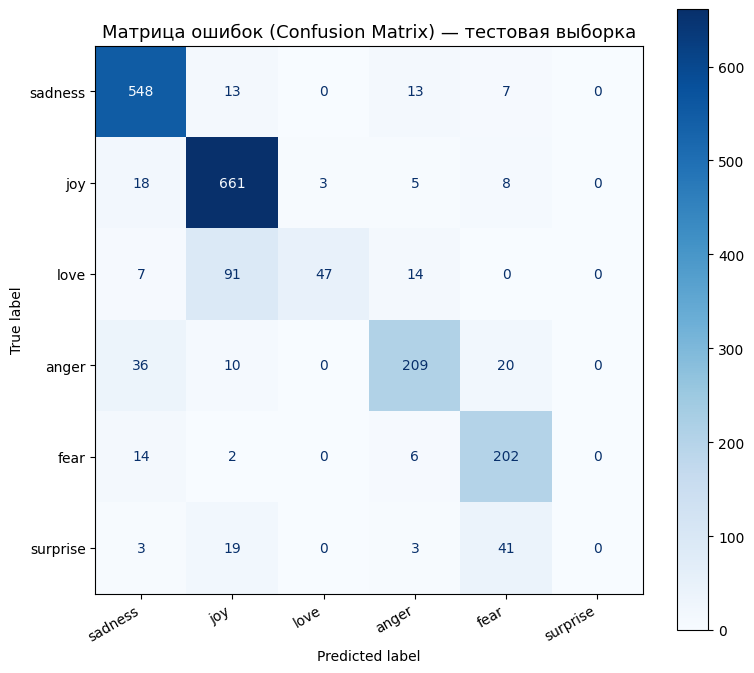

Матрица ошибок сохранена: c:\Users\tema\nano-banana\homeworks\HW13\artifacts\confusion_matrix.png


In [50]:
# Матрица ошибок
cm = confusion_matrix(true_labels, pred_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)

fig, ax = plt.subplots(figsize=(8, 7))
disp.plot(ax=ax, cmap="Blues", colorbar=True)
ax.set_title("Матрица ошибок (Confusion Matrix) — тестовая выборка", fontsize=13)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

# Сохранение
confusion_matrix_path = str(ARTIFACTS_DIR / "confusion_matrix.png")
plt.savefig(confusion_matrix_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Матрица ошибок сохранена: {confusion_matrix_path}")


In [51]:
# 10 примеров предсказаний
import torch.nn.functional as F

test_texts = raw_dataset["test"]["text"]
confidences = F.softmax(torch.tensor(pred_logits), dim=-1).numpy()
max_confidences = confidences.max(axis=1)

print("10 примеров предсказаний на тестовой выборке:")
print("-" * 80)
for i in range(10):
    text = test_texts[i]
    true = id2label[true_labels[i]]
    pred = id2label[pred_labels[i]]
    conf = max_confidences[i]
    status = "OK" if true == pred else "WRONG"
    print(f"[{status}] Текст: {text[:60]}..." if len(text) > 60 else f"[{status}] Текст: {text}")
    print(f"       Истина: {true} | Предсказание: {pred} | Уверенность: {conf:.3f}")
    print()

10 примеров предсказаний на тестовой выборке:
--------------------------------------------------------------------------------
[OK] Текст: im feeling rather rotten so im not very ambitious right now
       Истина: sadness | Предсказание: sadness | Уверенность: 0.861

[OK] Текст: im updating my blog because i feel shitty
       Истина: sadness | Предсказание: sadness | Уверенность: 0.921

[OK] Текст: i never make her separate from me because i don t ever want ...
       Истина: sadness | Предсказание: sadness | Уверенность: 0.926

[OK] Текст: i left with my bouquet of red and yellow tulips under my arm...
       Истина: joy | Предсказание: joy | Уверенность: 0.894

[OK] Текст: i was feeling a little vain when i did this one
       Истина: sadness | Предсказание: sadness | Уверенность: 0.900

[OK] Текст: i cant walk into a shop anywhere where i do not feel uncomfo...
       Истина: fear | Предсказание: fear | Уверенность: 0.476

[OK] Текст: i felt anger when at the end of a telephone cal

## 6. Сохранение артефактов

Сохраняем предсказания модели на тестовой выборке в CSV-файл для дальнейшего анализа.

In [52]:
# Формируем DataFrame с предсказаниями
sample_predictions_df = pd.DataFrame({
    "text": test_texts,
    "true_label": [id2label[l] for l in true_labels],
    "pred_label": [id2label[l] for l in pred_labels],
    "confidence": max_confidences.round(4),
})

print(f"Всего предсказаний: {len(sample_predictions_df)}")
print(f"Правильных: {(sample_predictions_df['true_label'] == sample_predictions_df['pred_label']).sum()} ({test_accuracy*100:.1f}%)")
print()
print("Первые 5 строк:")
print(sample_predictions_df.head())

Всего предсказаний: 2000
Правильных: 1667 (83.4%)

Первые 5 строк:
                                                text true_label pred_label  \
0  im feeling rather rotten so im not very ambiti...    sadness    sadness   
1          im updating my blog because i feel shitty    sadness    sadness   
2  i never make her separate from me because i do...    sadness    sadness   
3  i left with my bouquet of red and yellow tulip...        joy        joy   
4    i was feeling a little vain when i did this one    sadness    sadness   

   confidence  
0      0.8607  
1      0.9211  
2      0.9260  
3      0.8939  
4      0.9004  


In [53]:
# Сохранение CSV
csv_path = str(ARTIFACTS_DIR / "sample_predictions.csv")
sample_predictions_df.to_csv(csv_path, index=False, encoding="utf-8")
print(f"Предсказания сохранены: {csv_path}")

# Итоговый отчёт
print("\n" + "=" * 50)
print("ИТОГИ ЭКСПЕРИМЕНТА")
print("=" * 50)
print(f"Модель: {MODEL_NAME}")
print(f"Датасет: emotion (6 классов)")
print(f"Training: max_steps={training_args.max_steps}, train_bs={training_args.per_device_train_batch_size}, lr={training_args.learning_rate}")
print(f"Test Accuracy:  {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"Test F1-macro:  {test_f1_macro:.4f}")
print()
print("Сохранённые артефакты:")
print(f"  - {csv_path}")
print(f"  - {confusion_matrix_path}")
print("=" * 50)

Предсказания сохранены: c:\Users\tema\nano-banana\homeworks\HW13\artifacts\sample_predictions.csv

ИТОГИ ЭКСПЕРИМЕНТА
Модель: distilbert-base-uncased
Датасет: emotion (6 классов)
Training: max_steps=200, train_bs=16, lr=5e-05
Test Accuracy:  0.8335 (83.35%)
Test F1-macro:  0.6409

Сохранённые артефакты:
  - c:\Users\tema\nano-banana\homeworks\HW13\artifacts\sample_predictions.csv
  - c:\Users\tema\nano-banana\homeworks\HW13\artifacts\confusion_matrix.png
